In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

In [12]:
# 1. Load a sample image (Grayscale is best for visualizing pure kernel effects)
# We use the built-in 'camera' image from skimage
# image = data.camera()


# 1. Create a simple, high-contrast synthetic image
# Start with a 400x400 pure black image
image = np.zeros((400, 400), dtype=np.uint8)

# Add a stark white square (creates sharp, straight edges)
cv2.rectangle(image, (50, 50), (200, 200), 255, -1)

# Add a gray circle (creates curved edges and lower contrast)
cv2.circle(image, (280, 120), 70, 128, -1)

# Add a thick white diagonal line (creates angled edges)
cv2.line(image, (50, 350), (350, 250), 255, 20)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(400, 400), dtype=uint8)

In [13]:
# 2. Define the Kernels
# Kernels are typically 3x3 or 5x5 matrices. The numbers dictate how the 
# center pixel reacts to its neighbors.
kernels = {
    "Original (Identity)": np.array([
        [0,  0,  0],
        [0,  1,  0],
        [0,  0,  0]
    ]),
    
    "Sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ]),
    
    "Edge Detection": np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ]),
    
    "Emboss": np.array([
        [-2, -1,  0],
        [-1,  1,  1],
        [ 0,  1,  2]
    ]),
    
    "Box Blur (5x5)": np.ones((5, 5), np.float32) / 25.0,
    
    "Gaussian Blur (3x3 approximation)": np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ]) / 16.0
}

In [14]:
# 3. Setup the Matplotlib Figure
plt.figure(figsize=(15, 10))
plt.suptitle("Image Convolution with Different Kernels", fontsize=16)

Text(0.5, 0.98, 'Image Convolution with Different Kernels')

<Figure size 1500x1000 with 0 Axes>

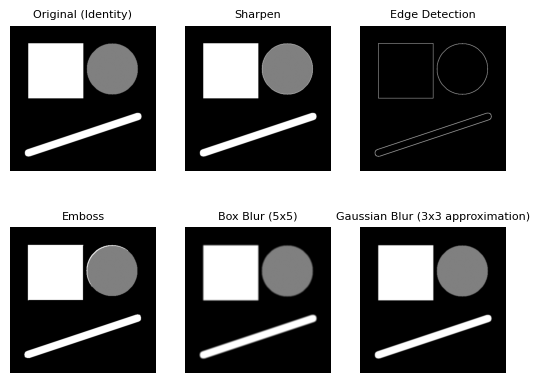

In [15]:
# 4. Apply each kernel and plot the results
for i, (name, kernel) in enumerate(kernels.items(), 1):
    # cv2.filter2D applies the kernel to the image. 
    # -1 means the output image will have the same depth as the source.
    filtered_image = cv2.filter2D(image, -1, kernel)
    
    # Plotting
    plt.subplot(2, 3, i)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(name, fontsize=8)
    plt.axis('off') # Hide axes for a cleaner look

In [6]:
# Adjust layout and display
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

<Figure size 640x480 with 0 Axes>